In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- Estilo visual global ---
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.labelsize"] = 11

# --- Silenciar warnings menores ---
import warnings
warnings.filterwarnings("ignore")

print("✅ Librerías cargadas correctamente")
print(f"   Pandas   : {pd.__version__}")
print(f"   NumPy    : {np.__version__}")
print(f"   Seaborn  : {sns.__version__}")

✅ Librerías cargadas correctamente
   Pandas   : 3.0.3
   NumPy    : 2.4.6
   Seaborn  : 0.13.2


Sec. 1.1

In [ ]:
#Despues de leer el dataset, revisamos las primeras filas para entender la estructura y el contenido
df.head()

,ID,Jugador,Equipo,Posicion,Nacionalidad,Edad,Partidos_Jugados,Goles,Asistencias,Minutos_Jugados,Tarjetas_Amarillas,Tarjetas_Rojas,Altura_cm,Peso_kg,Rating_Promedio,Valor_Mercado_Millones_EUR
0,1,Jugador_001,Tigres SC,Mediocampista,Inglaterra,17,25,1,2.0,1125,2,0,171,76,6.03,5.12
1,2,Jugador_002,Aguilas FC,Portero,Chile,23,18,0,3.0,846,3,0,180,85,6.28,1.48
2,3,Jugador_003,Tigres SC,Defensa,Argentina,28,0,1,2.0,0,2,0,179,74,7.01,4.40
3,4,Jugador_004,Halcones CF,Defensa,Argentina,30,35,4,2.0,2695,3,0,182,74,7.36,4.15
4,5,Jugador_005,Aguilas FC,Defensa,Italia,35,14,2,3.0,840,3,0,170,75,6.17,2.31


Sec. 1.2

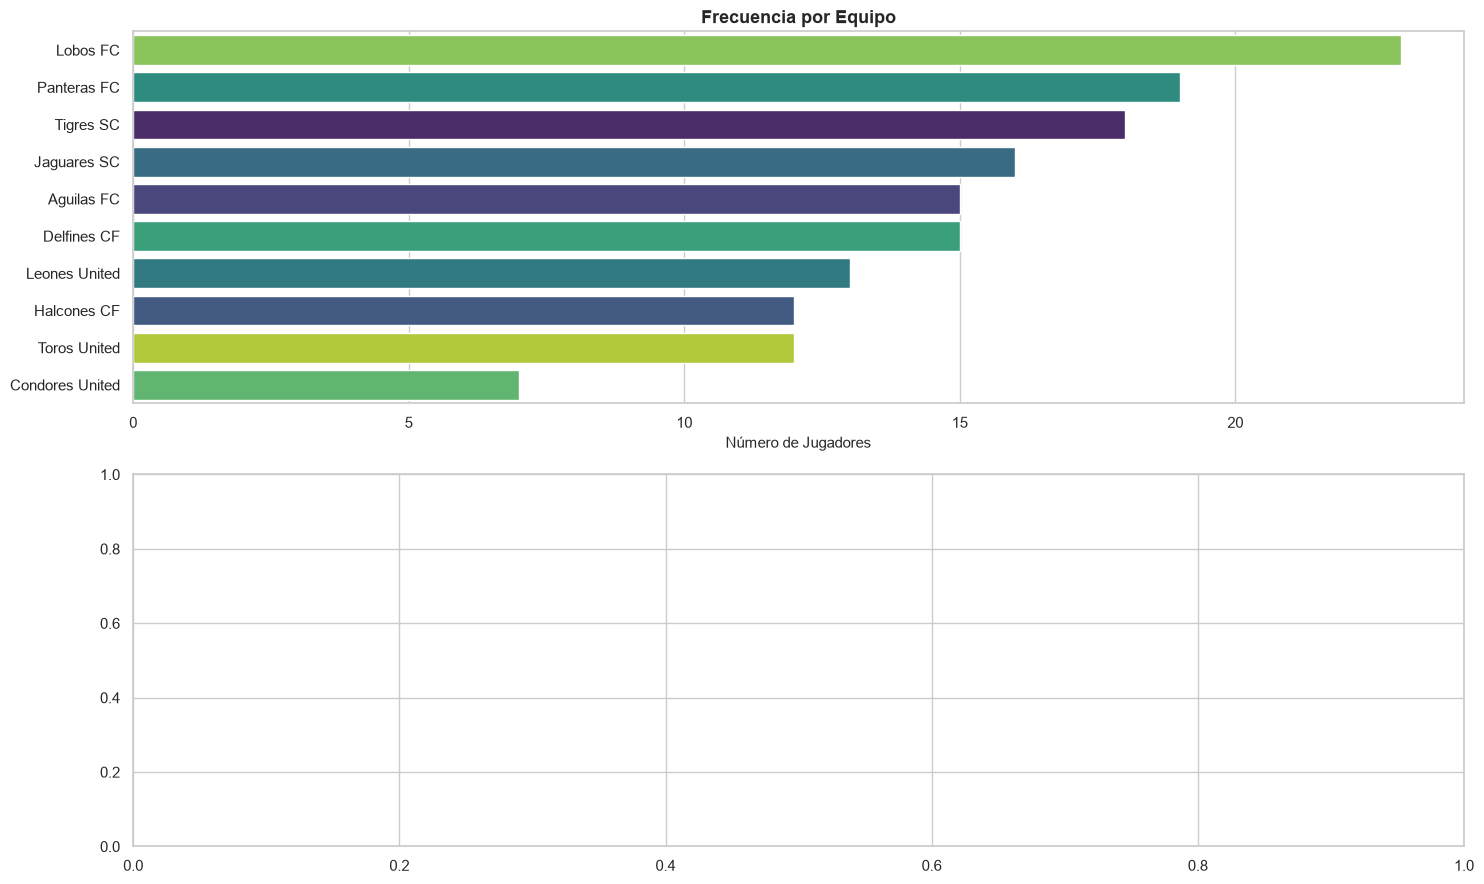

In [ ]:
#Con la información podemos empezar a interpretar los datos.
#Por ejemplo, al analizar la columna "Equipo", podemos ver la relación entre los equipos y la cantidad de jugadores que tienen.
fig, axes = plt.subplots(2, 1, figsize=(15, 9))

# Orden descendente para lectura fácil
for ax, var in zip(axes.flatten(), ["Equipo"]):
    orden = df[var].value_counts().index
    sns.countplot(data=df, y=var, order=orden, ax=ax, palette="viridis", hue=var, legend=False)
    ax.set_title(f"Frecuencia por {var}")
    ax.set_xlabel("Número de Jugadores")
    ax.set_ylabel("")

plt.tight_layout()
plt.show()

Sec. 1.3

In [ ]:
#Ya que el dataset es tan grande, revisamos el tamaño de la matriz.
df=pd.read_csv("dataset_futbol_jugadores.csv")
df.shape

(150, 16)

Sec. 1.4

In [ ]:
#Identificamos el tipo de dato de cada uno de nuestros valores.
df.dtypes

ID                              int64
Jugador                           str
Equipo                            str
Posicion                          str
Nacionalidad                      str
Edad                            int64
Partidos_Jugados                int64
Goles                           int64
Asistencias                   float64
Minutos_Jugados                 int64
Tarjetas_Amarillas              int64
Tarjetas_Rojas                  int64
Altura_cm                       int64
Peso_kg                         int64
Rating_Promedio               float64
Valor_Mercado_Millones_EUR    float64
dtype: object

Sec. 1.5

In [ ]:
#Identificamos la cantidad de valores nulos por columna para identificar datos faltantes.
df.isnull().sum()

ID                            0
Jugador                       0
Equipo                        0
Posicion                      0
Nacionalidad                  3
Edad                          0
Partidos_Jugados              0
Goles                         0
Asistencias                   9
Minutos_Jugados               0
Tarjetas_Amarillas            0
Tarjetas_Rojas                0
Altura_cm                     0
Peso_kg                       0
Rating_Promedio               5
Valor_Mercado_Millones_EUR    6
dtype: int64

El dataset cuenta con 23 valores nulos
Y la columna asistencias con 9

In [ ]:
df.duplicated().sum()

np.int64(0)

Sec. 1.6

In [ ]:
#Con la descripción, podemos ver la media, mediana, desviación estándar, valores máximos y mínimos, y los percentiles de cada columna numérica.
df.describe()

,ID,Edad,Partidos_Jugados,Goles,Asistencias,Minutos_Jugados,Tarjetas_Amarillas,Tarjetas_Rojas,Altura_cm,Peso_kg,Rating_Promedio,Valor_Mercado_Millones_EUR
count,150.000000,150.000000,150.000000,150.000000,141.000000,150.000000,150.000000,150.000000,150.000000,150.000000,145.000000,144.000000
mean,75.500000,28.053333,19.586667,3.940000,3.007092,1283.953333,3.013333,0.226667,179.513333,75.360000,6.829034,7.825417
std,43.445368,7.271150,11.156716,4.338419,1.758638,796.460107,1.404626,0.420078,6.629947,7.111084,0.599229,14.728567
min,1.000000,17.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,163.000000,60.000000,5.540000,0.300000
25%,38.250000,22.000000,12.000000,1.000000,2.000000,712.500000,2.000000,0.000000,175.000000,71.000000,6.440000,2.762500
50%,75.500000,28.000000,20.000000,3.000000,3.000000,1157.000000,3.000000,0.000000,179.000000,75.000000,6.820000,4.710000
75%,112.750000,34.000000,29.000000,6.000000,4.000000,1900.500000,4.000000,0.000000,184.000000,81.000000,7.210000,8.882500
max,150.000000,40.000000,38.000000,34.000000,9.000000,3293.000000,7.000000,1.000000,197.000000,96.000000,8.160000,129.050000


Sec. 2.1

In [ ]:
#Ahora identificamos la media de goles.
df["Goles"].mean()

np.float64(3.94)

El promedio de la columna Goles es de 3.94

Sec. 2.2

In [ ]:
#Con value_counts podemos ver la cantidad de jugadores en cada posición.
df["Posicion"].value_counts()

Posicion
Mediocampista    52
Defensa          49
Delantero        34
Portero          15
Name: count, dtype: int64

La posición con mayor cantidad de jugadores es la posición de mediocampista con 52 jugadores

Sec. 2.3

<Axes: xlabel='Valor_Mercado_Millones_EUR', ylabel='Count'>

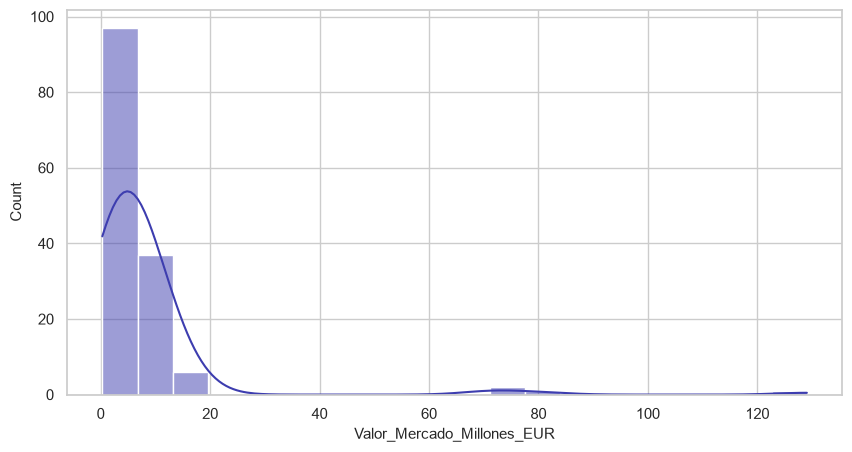

In [ ]:
#Con la información de la columna "Valor_Mercado_Millones_EUR", podemos visualizar la distribución de los valores de mercado de los jugadores.
sns.histplot(data=df, x="Valor_Mercado_Millones_EUR", bins=20, kde=True, color="#3D3DAF")

Sec. 2.4

In [ ]:
#Con la media del valor de mercado, podemos darnos una idea del valor medio sin la influencia de los valores extremos.
df["Valor_Mercado_Millones_EUR"].median()

np.float64(4.71)

La mediana del valor de mercado es de 4.71 millones de euros

Sec. 2.5

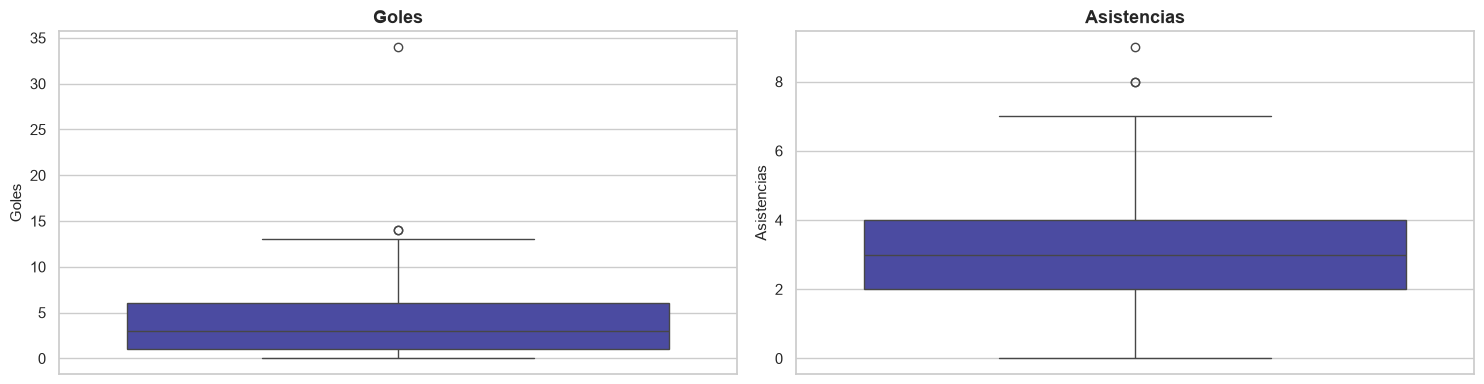

In [ ]:
#Con los boxplots podemos comparar los valores atípicos en las columnas "Goles" y "Asistencias".
fig, axes = plt.subplots(1, 2, figsize=(15, 4))
sns.boxplot(data=df, y="Goles", color="#3D3DAF", ax=axes[0])
axes[0].set_title("Goles")
sns.boxplot(data=df, y="Asistencias", color="#3D3DAF")
axes[1].set_title("Asistencias")

plt.tight_layout()
plt.show()

Sec. 3.1

In [ ]:
#Analizamos la correlación entre las variables numéricas del dataset para identificar la relación entre ellas.
variables_corr = ["Goles", "Asistencias", "Valor_Mercado_Millones_EUR", "Edad", "Partidos_Jugados", "Minutos_Jugados"]

matriz_corr = df[variables_corr].corr(method="pearson")
matriz_corr.round(2)

,Goles,Asistencias,Valor_Mercado_Millones_EUR,Edad,Partidos_Jugados,Minutos_Jugados
Goles,1.00,0.32,0.60,-0.15,-0.03,0.02
Asistencias,0.32,1.00,0.25,-0.10,-0.03,-0.03
Valor_Mercado_Millones_EUR,0.60,0.25,1.00,-0.15,0.05,0.10
Edad,-0.15,-0.10,-0.15,1.00,-0.02,-0.01
Partidos_Jugados,-0.03,-0.03,0.05,-0.02,1.00,0.89
Minutos_Jugados,0.02,-0.03,0.10,-0.01,0.89,1.00


Sec. 3.2

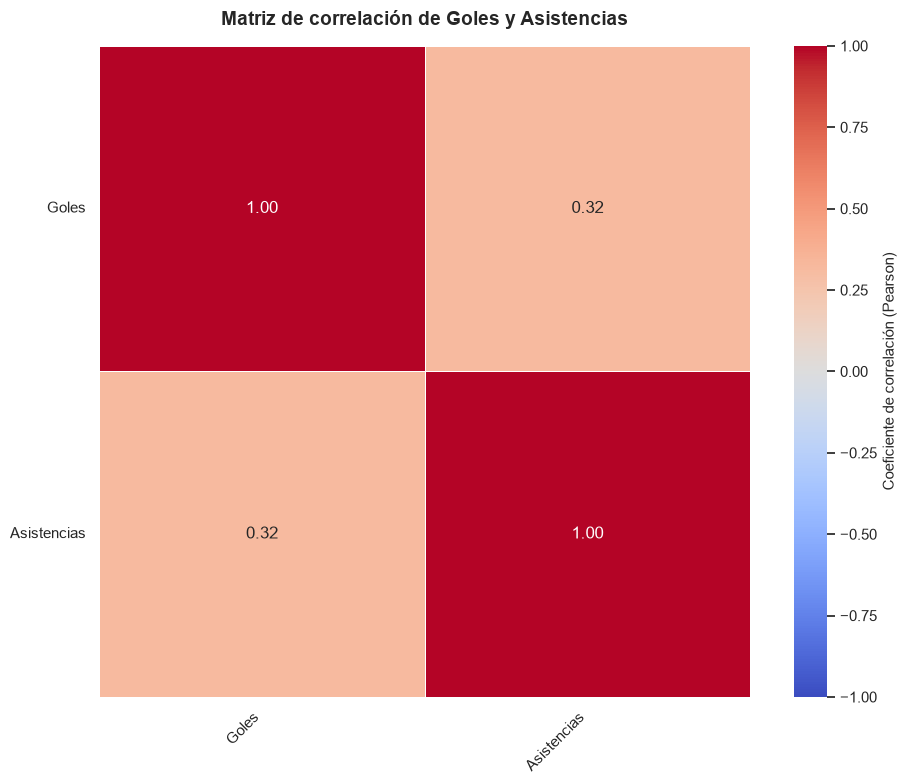

In [ ]:
#Con el heatmap visualizamos la correlación de forma mucho más directa para las variables de interés.
plt.figure(figsize=(10, 8))
sns.heatmap(
    matriz_corr,
    annot=True,
    cmap="coolwarm",
    center=0,
    vmin=-1, vmax=1,
    fmt=".2f",
    linewidths=0.5,
    square=True,
    cbar_kws={"label": "Coeficiente de correlación (Pearson)"},
)
plt.title("Matriz de correlación de Goles y Asistencias", fontsize=14, pad=15)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

A pesar de que no es una relación muy fuerte, la relación entre goles y asistencias si es positiva

Sec. 3.3

<Axes: xlabel='Goles', ylabel='Asistencias'>

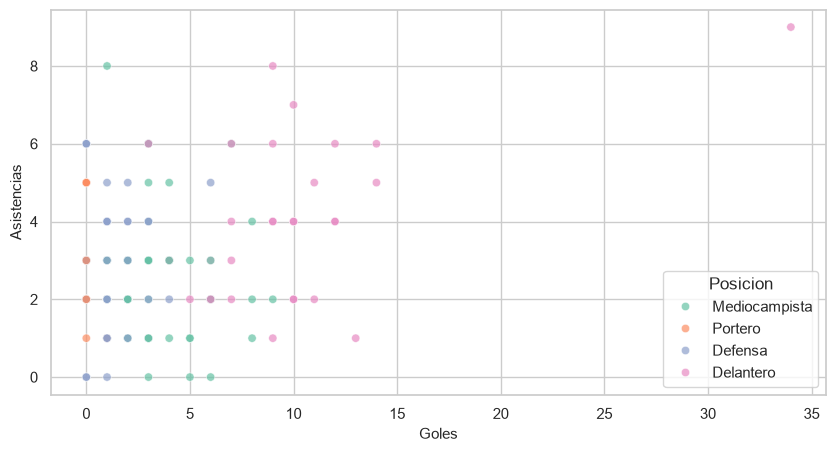

In [ ]:
#Analizamos la disperción de los datos de Goles y Asistencias según la posición para identificar patrones o relaciones entre estas variables.
sns.scatterplot(data=df, x="Goles", y="Asistencias", hue="Posicion", palette="Set2", alpha=0.7)

Sec. 3.4

In [ ]:
#Analizamos los outliers de la columna "Valor_Mercado_Millones_EUR" para identificar valores extremos que puedan afectar el análisis.
col = df["Valor_Mercado_Millones_EUR"]
Q1 = col.quantile(0.25)
Q3 = col.quantile(0.75)
IQR = Q3 - Q1
Limite_inferior = Q1 - 1.5 * IQR
Limite_superior = Q3 + 1.5 * IQR
outliers = df[(col < Limite_inferior) | (col > Limite_superior)]
print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Límite inferior:", Limite_inferior)
print("Límite superior:", Limite_superior)
print("Outliers:")
print(outliers)
print(f"Cantidad de outliers: {outliers.shape[0]}")

Q1: 2.7625
Q3: 8.8825
IQR: 6.12
Límite inferior: -6.4174999999999995
Límite superior: 18.0625
Outliers:
      ID      Jugador         Equipo       Posicion Nacionalidad  Edad  \
6      7  Jugador_007  Leones United      Delantero     Portugal    18   
15    16  Jugador_016      Tigres SC  Mediocampista   Inglaterra    35   
64    65  Jugador_065       Lobos FC        Defensa      Uruguay    23   
131  132  Jugador_132    Halcones CF  Mediocampista     Alemania    18   

     Partidos_Jugados  Goles  Asistencias  Minutos_Jugados  \
6                   7     34          9.0              385   
15                 24      8          2.0             1704   
64                 37      1          2.0             3071   
131                33      6          3.0             2343   

     Tarjetas_Amarillas  Tarjetas_Rojas  Altura_cm  Peso_kg  Rating_Promedio  \
6                     1               0        182       79             6.54   
15                    1               1        182    

La cantidad de outliers en el Valor de mercado en millones de euros son 4

Sec. 4.1

In [33]:
df["Edad"].mean()

np.float64(28.053333333333335)

Sec. 4.2

La edad promedio de los jugadores es de 28 años

In [34]:
df["Asistencias"].dtype

dtype('float64')


| # | Hallazgo (qué vimos) | Evidencia (qué gráfico lo muestra) | Motivo o acción a tomar |
|---|----------------------|------------------------------------|------------------------|
| 1 | *La variable de Asistencias cuenta con la mayor cantidad de valores nulos* | Sec 1.4 | Están ocurriendo goles sin un pase previo |
| 2 |*El quipo con mayor cantidad de jugadores es Lobos FC* | Sec. 1.2 | Los demás equipos deberían pensar en traer más jugadores|
| 3 |*Los outliers de Goles están mucho más lejos de la media que los de Asistencias* | Sec. 2.5 | Seguramente sea porque un gol por encima del promedio destaca mucho más que una asistencia|
| 4 |*La relación de goles y asistencias de los jugadores es mucho más dispersa pa4a los delanteros* | Sec. 3.3 |Mientras que los jugadores de otras posiciones tienden a pasarla y mantener su ratio constante, los delanteros son impredecibles en si tirarán a puerta o la pasarán |
| 5 |*La correlación más fuerte es la de goles y valor de mercado en millones de euros* | Sec. 3.1 | El valor de mercado de un jugador se ve muy reflejado en su capacidad para marcar gol (especialmente los delanteros) |
